In [ ]:
import pandas as pd 
import numpy as np 
from matplotlib import pyplot as plt

In [7]:
df= pd.read_csv('height-weight.csv')
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0.5, 1.0, 'weight-height scatter plot')

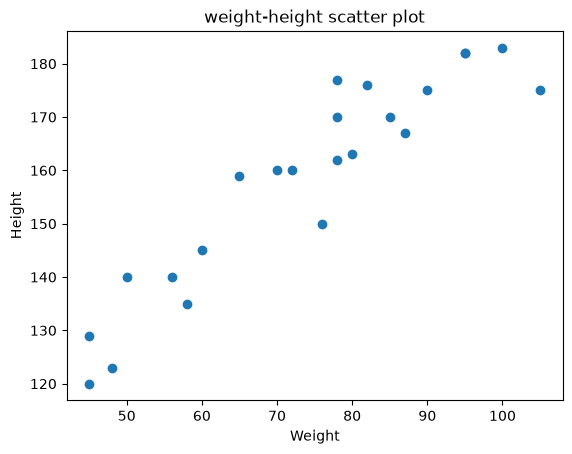

In [9]:
plt.scatter(df['Weight'], df['Height'])
plt.xlabel('Weight')
plt.ylabel('Height')
plt.title('weight-height scatter plot')

In [10]:
# correlation bewtween weight and height
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


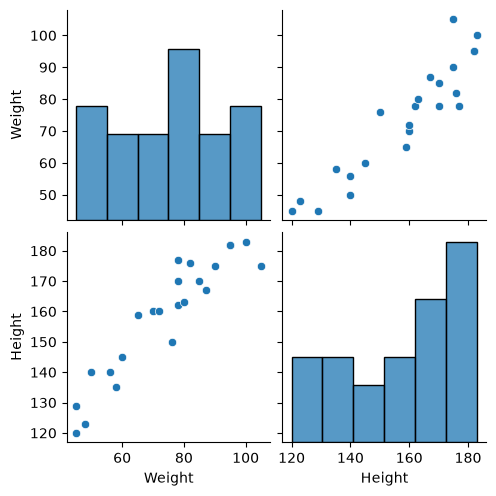

In [11]:
import seaborn as sns 

sns.pairplot(df)

In [13]:
# independent and dependent features 
x_series = df[['Weight']] # The independent feature is must be an array of 2D shape or dataframe 
y_series = df[['Height']] # The dependent feature is must be an array of 1D shape or series

np.array(x_series).shape
np.array(y_series).shape

(23, 1)

In [14]:
from sklearn.model_selection import train_test_split 

In [17]:
x_train, x_test, y_train, y_test = train_test_split(x_series, y_series, test_size=0.25, random_state=42)

In [18]:
x_train.shape

(17, 1)

In [20]:
# standardization of the data
from sklearn.preprocessing import StandardScaler

In [21]:
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [22]:
x_test

array([[ 0.33497168],
       [ 0.33497168],
       [-1.6641678 ],
       [ 1.36483141],
       [-0.45256812],
       [ 1.97063125]])

In [23]:
# Apply simple Linear Regression model
from sklearn.linear_model import LinearRegression 

In [24]:
regression = LinearRegression(n_jobs = -1)
regression.fit(x_train, y_train)


,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",-1
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 1)",[[17.3]]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[156.47]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[4.12]


In [25]:
print(f"the coefficent or slope of the line is : {regression.coef_}")
print(f"the intercept of the line is : {regression.intercept_}")

the coefficent or slope of the line is : [[17.2982057]]
the intercept of the line is : [156.47058824]


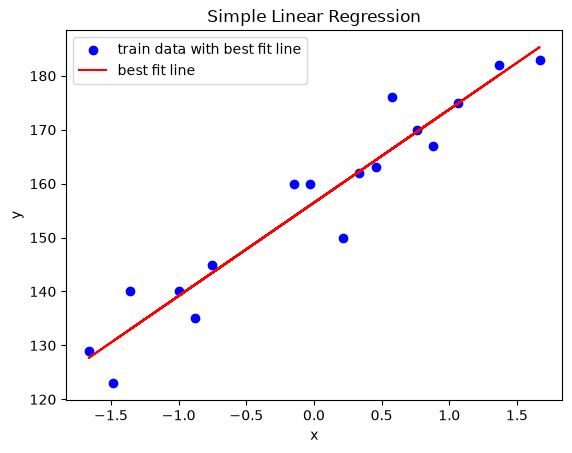

In [27]:
# plot the training data and best fit line
plt.scatter(x_train, y_train, color = 'blue', label = 'train data with best fit line')
plt.plot(x_train, regression.predict(x_train), color = 'red', label = 'best fit line')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Simple Linear Regression')
plt.legend()
plt.show()

### prediction of test data
1. predicted height output= intercept +coef_(Weights)
2. y_pred_test =156.470 + 17.29(X_test)

In [28]:
# predition on test data
y_pred = regression.predict(x_test)

In [29]:
# preformance metrics for regression model 

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

## R square 
Formula

**R^2 = 1 - SSR/SST**


R^2	=	coefficient of determination
SSR	=	sum of squares of residuals
SST	=	total sum of squares

In [30]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse}")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"R-squared (R2): {r2}")

Mean Squared Error (MSE): 114.84069295228699
Mean Absolute Error (MAE): 9.66512588679501
Root Mean Squared Error (RMSE): 10.716374991212605
R-squared (R2): 0.7360826717981276


**Adjusted R2 = 1 – [(1-R2)*(n-1)/(n-k-1)]**

where:

R2: The R2 of the model
n: The number of observations
k: The number of predictor variables

In [31]:
# display adjusted R-squared value
1 - (1-r2)*(len(y_test)-1)/(len(y_test)-x_test.shape[1]-1)

0.6701033397476595

In [32]:
# OLS Model Training

import statsmodels.api as sm

In [33]:
model = sm.OLS(y_train, x_train).fit()

In [34]:
# prediction on test data using OLS model
prediction = model.predict(x_test)

In [35]:
print("prediction of the model", prediction)

prediction of the model [  5.79440897   5.79440897 -28.78711691  23.60913442  -7.82861638
  34.08838469]


In [36]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.012
Model:                            OLS   Adj. R-squared (uncentered):             -0.050
Method:                 Least Squares   F-statistic:                             0.1953
Date:                Thu, 23 Jul 2026   Prob (F-statistic):                       0.664
Time:                        01:06:04   Log-Likelihood:                         -110.03
No. Observations:                  17   AIC:                                      222.1
Df Residuals:                      16   BIC:                                      222.9
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [37]:
## Prediction For new data
regression.predict(scaler.transform([[72]]))

c:\Users\battu\OneDrive\Desktop\ml and ai learning\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[155.97744705]])